<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/Insight-Sogang-Univ/insight-15th/blob/main/advanced/template/session07/practice_recsys.ipynb" target="_parent">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
  </td>
</table>

# 🎬 추천 시스템 종합 실습

이 노트북에서는 추천 시스템의 핵심 알고리즘들을 **직접 구현**하며 원리를 체득합니다.

---

## 📋 실습 목차

| 실습 | 주제 | 핵심 개념 |
|------|------|----------|
| **실습 1** | 내용 기반 필터링 (Content-Based Filtering) | TF-IDF, 코사인 유사도 |
| **실습 2A** | SVD로 잠재 요인 시각화 | 행렬 분해, 잠재 공간 |
| **실습 2B** | PyTorch 임베딩 기반 행렬 분해 | `nn.Embedding`, MSE 학습 |
| **실습 2C** | LightGCN 그래프 전파 1스텝 + 시각화 | 이분 그래프, 정규화 집계 |

---

> **📌 `***` 로 표시된 부분만 채워서 실습을 완성해보세요!**
>
> - 주변 코드와 주석을 읽으면 쉽게 알 수 있어요!

## ⚙️ 환경 설정

아래 셀을 실행하여 필요한 라이브러리를 설치합니다.

In [4]:
# 필요한 라이브러리 설치
!pip install torch pandas numpy scipy scikit-learn tqdm pyvis -q

# ── 실습 2: MovieLens 100K 다운로드 ───────────────────────────────────
import os, zipfile, urllib.request
DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)
url = "http://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_path = os.path.join(DATA_DIR, "ml-100k.zip")
if not os.path.exists(os.path.join(DATA_DIR, "ml-100k")):
    if not os.path.exists(zip_path):
        print("MovieLens 100K 다운로드 중...")
        urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(DATA_DIR)
    print("MovieLens 100K 다운로드 완료!")
else:
    print("MovieLens 100K 이미 존재")

print("\n✅ 환경 설정 완료!")


MovieLens 100K 이미 존재

✅ 환경 설정 완료!


---

# 🎯 실습 1: 내용 기반 필터링 (Content-Based Filtering)

**데이터셋**: TMDB 5000 Movies  
**학습 목표**:
1. TF-IDF가 단순 원-핫 인코딩과 **왜 다른지** 데이터로 직접 확인한다
2. 코사인 유사도로 아이템 간 유사도를 계산하는 원리를 이해한다
3. 특정 영화를 입력하면 유사한 영화를 추천하는 함수를 완성한다

### 📖 개념 복습
- **TF-IDF**: '이 문서에서만 자주 나오는 단어'에 높은 가중치를 부여
  - **TF(d, t)**: 문서 d에서 단어 t가 등장한 횟수
  - **IDF(d, t)**: $\log\left(\frac{n}{1 + df(t)}\right)$ — 모든 문서에서 흔한 단어는 중요도 낮춤
- **코사인 유사도**: 두 벡터의 각도로 유사도 측정 (1에 가까울수록 유사)

In [5]:
# ===== 실습 1 - Step 1: 데이터 불러오기 =====

import pandas as pd
import numpy as np

movies_df = pd.read_csv('tmdb_5000_movies.csv')

print(f"데이터 크기: {movies_df.shape}")
movies_df.head(3)

데이터 크기: (4803, 20)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466


In [6]:
# ===== 실습 1 - Step 2: 데이터 전처리 =====

# 필요한 컬럼만 선택 + 결측치 제거
selected_columns = ['id', 'title', 'genres', 'keywords']
movies_df = movies_df[selected_columns].dropna().reset_index(drop=True)

# genres, keywords 컬럼 미리보기
print("장르 예시:")
print(movies_df['genres'][0][:100], "...\n")

print("키워드 예시:")
print(movies_df['keywords'][0][:100], "...")

장르 예시:
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name": "Fantasy"}, {"id" ...

키워드 예시:
[{"id": 1463, "name": "culture clash"}, {"id": 2964, "name": "future"}, {"id": 3386, "name": "space  ...


In [7]:
# ===== 실습 1 - Step 3: content 피처 생성 =====
#
# genres와 keywords 컬럼은 JSON 문자열 형태입니다.
#   예) '[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}]'
#
# 그냥 붙이면 "id", "name", 숫자 같은 노이즈 토큰이 TF-IDF에 들어가므로,
# ast.literal_eval 로 파싱해서 name 값만 추출합니다.

import ast

def parse_json_col(text):
    """JSON 문자열에서 name 필드만 추출해 공백 구분 소문자 문자열로 반환"""
    try:
        items = ast.literal_eval(text)
        return " ".join([x["name"].lower().replace(" ", "") for x in items])
    except:
        return ""

movies_df["genres_clean"]   = movies_df["genres"].apply(parse_json_col)
movies_df["keywords_clean"] = movies_df["keywords"].apply(parse_json_col)
movies_df["content"]        = movies_df["genres_clean"] + " " + movies_df["keywords_clean"]

# 파싱 전후 비교
print("=== 파싱 전 (raw genres) ===")
print(movies_df["genres"].iloc[0][:80], "...")
print()
print("=== 파싱 후 (genres_clean) ===")
print(movies_df["genres_clean"].iloc[0])
print()
print("=== content 예시 (Avatar) ===")
avatar_row = movies_df[movies_df["title"] == "Avatar"]
print(avatar_row["content"].values[0][:200], "...")


=== 파싱 전 (raw genres) ===
[{"id": 28, "name": "Action"}, {"id": 12, "name": "Adventure"}, {"id": 14, "name ...

=== 파싱 후 (genres_clean) ===
action adventure fantasy sciencefiction

=== content 예시 (Avatar) ===
action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar power ...


In [8]:
# ===== 실습 1 - Step 4: TF-IDF vs 원-핫 인코딩 비교 =====
#
# 🔎 왜 TF-IDF인가? 같은 단어 집합으로 두 값을 직접 비교해봅시다.

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# 먼저 TF-IDF로 상위 15개 단어 집합을 결정합니다.
tfidf_ref = TfidfVectorizer(stop_words="english", max_features=15)
tfidf_ref.fit(movies_df["content"])
shared_vocab = tfidf_ref.vocabulary_  # {단어: 인덱스}

# 같은 vocabulary를 강제로 지정해서 두 방식 모두 동일한 15개 단어 사용
count_vectorizer = CountVectorizer(vocabulary=shared_vocab)
tfidf_vectorizer = TfidfVectorizer(vocabulary=shared_vocab)

count_matrix = count_vectorizer.fit_transform(movies_df["content"])
tfidf_matrix = tfidf_vectorizer.fit_transform(movies_df["content"])

# Avatar (첫 번째 행)의 두 벡터 비교
feature_names = tfidf_vectorizer.get_feature_names_out()
count_vec = count_matrix[0].toarray()[0]
tfidf_vec = tfidf_matrix[0].toarray()[0]

import pandas as pd
compare_df = pd.DataFrame({
    "단어": feature_names,
    "카운트(원핫)": count_vec.astype(int),
    "TF-IDF 값": tfidf_vec.round(4)
}).query("`카운트(원핫)` > 0 or `TF-IDF 값` > 0")  # 0인 행 제거

print("=" * 55)
print("Avatar 벡터 비교 (같은 단어 기준, 등장한 단어만 표시)")
print("=" * 55)
print(compare_df.to_string(index=False))
print()
print("💡 관찰 포인트:")
print("  - 카운트는 단순 등장 횟수 (0 또는 1)")
print("  - TF-IDF는 '이 영화에서만 특별히 자주 나오는 단어'에 더 높은 값")
print("  - 많은 영화에서 공통으로 나오는 장르 단어일수록 TF-IDF가 낮아짐")


Avatar 벡터 비교 (같은 단어 기준, 등장한 단어만 표시)
            단어  카운트(원핫)  TF-IDF 값
        action        1    0.3715
     adventure        1    0.4284
       fantasy        1    0.5221
       romance        1    0.4085
sciencefiction        1    0.4889

💡 관찰 포인트:
  - 카운트는 단순 등장 횟수 (0 또는 1)
  - TF-IDF는 '이 영화에서만 특별히 자주 나오는 단어'에 더 높은 값
  - 많은 영화에서 공통으로 나오는 장르 단어일수록 TF-IDF가 낮아짐


In [9]:
# ===== 실습 1 - Step 5: 전체 데이터 TF-IDF 행렬 생성 =====

# 이번엔 max_features 제한 없이 전체 어휘로 TF-IDF 행렬을 만든다.
tfidf_full = TfidfVectorizer(stop_words='english', lowercase=True)
tfidf_full_matrix = tfidf_full.fit_transform(movies_df['content'])

print(f"TF-IDF 행렬 크기: {tfidf_full_matrix.shape}")
print(f"  → {tfidf_full_matrix.shape[0]}편 영화 × {tfidf_full_matrix.shape[1]}개 단어")

TF-IDF 행렬 크기: (4803, 9769)
  → 4803편 영화 × 9769개 단어


In [10]:
# ===== 실습 1 - Step 6: 코사인 유사도 행렬 계산 =====

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim = cosine_similarity(tfidf_full_matrix, tfidf_full_matrix)

print(f"유사도 행렬 크기: {cosine_sim.shape}")
print(f"  → {cosine_sim.shape[0]} × {cosine_sim.shape[1]} (영화 × 영화)")
print(f"\n자기 자신과의 유사도 (대각선): {cosine_sim[0, 0]:.4f}  (항상 1.0 = 완전히 동일)")
print(f"Avatar vs 첫 번째 다른 영화:  {cosine_sim[0, 1]:.4f}")

유사도 행렬 크기: (4803, 4803)
  → 4803 × 4803 (영화 × 영화)

자기 자신과의 유사도 (대각선): 1.0000  (항상 1.0 = 완전히 동일)
Avatar vs 첫 번째 다른 영화:  0.0271


### ✏️ 빈칸 채우기: 추천 함수 완성

코드의 `***` 부분을 채워서 완성해보세요.

| *** | 채워야 할 값 | 설명 |
|-----|------------|------|
| 1번째 `***` | `title` | 함수 인자로 받은 영화 제목 변수 |
| 2번째 `***` | `idx` | 위에서 찾은 영화의 인덱스 |
| 3번째 `***` | `True` | 높은 유사도부터 정렬 (내림차순) |
| 4~5번째 `***` | `1`, `11` | 자기자신(0번) 제외, 2~11위 선택 |


In [11]:
import pandas as pd
import numpy as np

# ===== 실습 1 - Step 7: 추천 함수 완성 =====

def content_based_filtering(title, cosine_sim=cosine_sim):
    """
    주어진 영화 제목과 유사한 영화 10편을 추천합니다.
    """

    # STEP 1: 제목으로 영화의 행 인덱스 찾기
    idx = movies_df[movies_df['title'] == ***].index[0]

    # STEP 2: 해당 영화와 모든 영화 간 유사도를 (인덱스, 점수) 리스트로 변환
    sim_scores = list(enumerate(cosine_sim[***]))

    # STEP 3: 유사도 점수 기준으로 내림차순 정렬
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=***)

    # STEP 4: 자기 자신(1위) 제외하고 상위 10개 선택
    sim_scores = sim_scores[***:***]

    # STEP 5: 선택된 인덱스로 영화 제목 반환
    movie_indices = [i[0] for i in sim_scores]
    return movies_df['title'].iloc[movie_indices]

In [12]:
# ===== 실습 1 - Step 8: 추천 함수 테스트 =====

# 여러 영화로 테스트해보세요!
test_movies = ['Avatar', 'The Dark Knight', 'Toy Story']

for movie in test_movies:
    print(f"\n🎬 '{movie}' 와 유사한 영화 TOP 10:")
    print("-" * 40)
    try:
        result = content_based_filtering(movie)
        for i, title in enumerate(result, 1):
            print(f"  {i:2d}. {title}")
    except Exception as e:
        print(f"  ❌ 에러: {e}")
        print("  → content_based_filtering 함수의 빈칸을 먼저 채워주세요!")


🎬 'Avatar' 와 유사한 영화 TOP 10:
----------------------------------------
   1. Star Trek Into Darkness
   2. A Monster in Paris
   3. Jupiter Ascending
   4. Predators
   5. The Astronaut's Wife
   6. The Lovers
   7. Stargate: The Ark of Truth
   8. Stranded
   9. Ender's Game
  10. The Time Machine

🎬 'The Dark Knight' 와 유사한 영화 TOP 10:
----------------------------------------
   1. The Dark Knight Rises
   2. Batman Begins
   3. Batman & Robin
   4. Batman
   5. Batman Returns
   6. Batman v Superman: Dawn of Justice
   7. Batman: The Dark Knight Returns, Part 2
   8. Kick-Ass 2
   9. Defendor
  10. Man of Steel

🎬 'Toy Story' 와 유사한 영화 TOP 10:
----------------------------------------
   1. Meet the Deedles
   2. Toy Story 3
   3. Pooh's Heffalump Movie
   4. Hey Arnold! The Movie
   5. Alpha and Omega: The Legend of the Saw Tooth Cave
   6. Ted
   7. The Pirates! In an Adventure with Scientists!
   8. Monster House
   9. Legend of a Rabbit
  10. Return to Never Land


### 🤔 생각해보기

1. 'Avatar'와 유사한 영화들의 공통점은 무엇인가요? TF-IDF가 어떤 단어에 집중했을까요?
2. 내용 기반 필터링의 **콜드스타트 문제**가 없는 이유는 무엇인가요?
3. 이 방식의 단점은 무엇이고, 어떻게 보완할 수 있을까요?

---

# 🔢 실습 2A: SVD로 잠재 요인(Latent Factor) 시각화

**데이터셋**: MovieLens 100K  
**학습 목표**:
- 유저-아이템 평점 행렬 $R$을 SVD로 분해해 잠재 요인(P, Q)의 의미를 이해한다
- rank-2 근사로 빈 평점을 채워보고, 잠재 공간을 2D로 시각화한다

### 📖 개념 복습
$$R \approx P \cdot Q^T$$
- $P$: 유저 잠재 요인 행렬 (유저 × k)
- $Q$: 아이템 잠재 요인 행렬 (아이템 × k)
- 두 벡터의 **내적** → 해당 유저의 해당 아이템에 대한 **예측 평점**

In [13]:
# ===== 실습 2A - Step 1: 데이터 불러오기 =====

import os  # DATA_DIR 경로 참조용
import pandas as pd
import numpy as np
from numpy.linalg import svd

# 평점 데이터
ratings_path = os.path.join(DATA_DIR, "ml-100k", "u.data")
ratings = pd.read_csv(
    ratings_path, sep="\t",
    names=["userId", "movieId", "rating", "timestamp"]
)
ratings["rating"] = ratings["rating"].astype(float)

# 영화 메타데이터
item_path = os.path.join(DATA_DIR, "ml-100k", "u.item")
movies = pd.read_csv(
    item_path, sep="|", header=None,
    encoding="latin-1", usecols=[0, 1]
)
movies.columns = ["movieId", "title"]

print(f"평점 데이터: {ratings.shape[0]:,}개 평점")
print(f"  유저 수: {ratings['userId'].nunique():,}명")
print(f"  영화 수: {ratings['movieId'].nunique():,}편")
print(f"  평균 평점: {ratings['rating'].mean():.2f}점")
ratings.head()

평점 데이터: 100,000개 평점
  유저 수: 943명
  영화 수: 1,682편
  평균 평점: 3.53점


,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596


In [14]:
# ===== 실습 2A - Step 2: 유저-아이템 평점 행렬 구성 =====

# 전체 행렬은 너무 크므로, 앞 8명 유저 × 앞 8개 영화만 샘플링합니다
user_ids = sorted(ratings["userId"].unique())
movie_ids = sorted(ratings["movieId"].unique())

sample_users = user_ids[:8]
sample_movies = movie_ids[:8]

# pivot_table: 행=userId, 열=movieId, 값=rating
R_sparse = ratings.pivot_table(
    values="rating", index="userId", columns="movieId"
)

# 샘플 블록만 추출 (NaN 유지)
R_block = R_sparse.loc[sample_users, sample_movies]

print("=== 원본 평점 블록 R (NaN = 아직 평가 안 한 영화) ===")
print(R_block.to_string())

=== 원본 평점 블록 R (NaN = 아직 평가 안 한 영화) ===
movieId    1    2    3    4    5    6    7    8
userId                                         
1        5.0  3.0  4.0  3.0  3.0  5.0  4.0  1.0
2        4.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN
3        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
5        4.0  3.0  NaN  NaN  NaN  NaN  NaN  NaN
6        4.0  NaN  NaN  NaN  NaN  NaN  2.0  4.0
7        NaN  NaN  NaN  5.0  NaN  NaN  5.0  5.0
8        NaN  NaN  NaN  NaN  NaN  NaN  3.0  NaN


In [15]:
# ===== 실습 2A - Step 3: SVD 수행 및 rank-2 근사 =====

# SVD는 NaN을 처리할 수 없으므로, global mean으로 NaN 채우기
global_mean = ratings["rating"].mean()
R_block_filled = R_block.fillna(global_mean).values  # numpy array로 변환

print(f"Global Mean: {global_mean:.3f}")
print(f"NaN 채운 후 행렬:\n{R_block_filled.round(2)}")

# SVD 수행: R ≈ U @ diag(S) @ Vt
U, S, Vt = svd(R_block_filled, full_matrices=False)

print(f"\nU 크기: {U.shape}  (유저 × 잠재차원)")
print(f"S 크기: {S.shape}   (특이값 벡터, 중요도 순 정렬)")
print(f"Vt 크기: {Vt.shape} (잠재차원 × 아이템)")
print(f"\n특이값(중요도): {S.round(2)}")
print(f"  → 상위 2개가 전체의 {(S[:2].sum()/S.sum()*100):.1f}% 차지")

Global Mean: 3.530
NaN 채운 후 행렬:
[[5.   3.   4.   3.   3.   5.   4.   1.  ]
 [4.   3.53 3.53 3.53 3.53 3.53 3.53 3.53]
 [3.53 3.53 3.53 3.53 3.53 3.53 3.53 3.53]
 [3.53 3.53 3.53 3.53 3.53 3.53 3.53 3.53]
 [4.   3.   3.53 3.53 3.53 3.53 3.53 3.53]
 [4.   3.53 3.53 3.53 3.53 3.53 2.   4.  ]
 [3.53 3.53 3.53 5.   3.53 3.53 5.   5.  ]
 [3.53 3.53 3.53 3.53 3.53 3.53 3.   3.53]]

U 크기: (8, 8)  (유저 × 잠재차원)
S 크기: (8,)   (특이값 벡터, 중요도 순 정렬)
Vt 크기: (8, 8) (잠재차원 × 아이템)

특이값(중요도): [28.74  3.62  2.11  0.72  0.48  0.25  0.06  0.  ]
  → 상위 2개가 전체의 89.9% 차지


In [16]:
# ===== 실습 2A - Step 4: rank-2 근사로 P, Q 추출 =====

k = 2  # 상위 2개 잠재 요인만 사용

U_k = U[:, :k]          # (8, 2)  상위 k개 유저 벡터
S_k = np.diag(S[:k])    # (2, 2)  상위 k개 특이값 (대각행렬)
V_k = Vt[:k, :].T       # (8, 2)  상위 k개 아이템 벡터 (전치)

# R ≈ P @ Q^T  형태로 맞추기
P = U_k @ S_k  # 유저 잠재 요인 행렬 (8 × 2)
Q = V_k        # 아이템 잠재 요인 행렬 (8 × 2)

P_df = pd.DataFrame(P, index=sample_users, columns=["f1", "f2"])
Q_df = pd.DataFrame(Q, index=sample_movies, columns=["f1", "f2"])

print("=== P 행렬 (유저 × 2 잠재요인) ===")
print(P_df.round(3))
print("\n=== Q 행렬 (영화 × 2 잠재요인) ===")
print(Q_df.round(3))

=== P 행렬 (유저 × 2 잠재요인) ===
       f1     f2
1  -9.988  3.170
2 -10.155 -0.053
3  -9.976 -0.240
4  -9.976 -0.240
5  -9.978 -0.018
6  -9.783 -0.506
7 -11.523 -1.607
8  -9.791 -0.275

=== Q 행렬 (영화 × 2 잠재요인) ===
      f1     f2
1 -0.382  0.398
2 -0.334 -0.065
3 -0.353  0.176
4 -0.361 -0.247
5 -0.341 -0.066
6 -0.365  0.419
7 -0.349  0.066
8 -0.342 -0.749


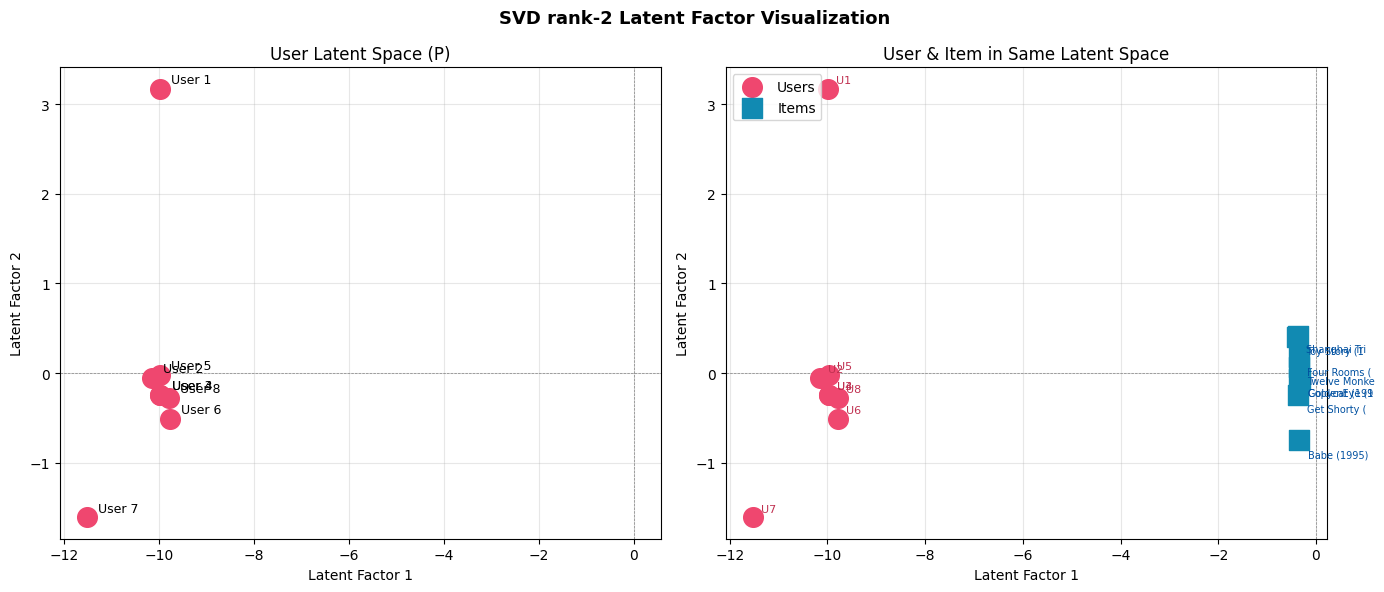


💡 유저와 아이템이 동일한 2D 잠재 공간에 표현됩니다.
   가까이 있을수록 = 유저가 그 아이템을 좋아할 가능성 높음!


In [17]:
# ===== 실습 2A - Step 5: 잠재 공간 시각화 =====

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- 왼쪽: 유저 잠재 공간 ---
ax = axes[0]
ax.scatter(P_df["f1"], P_df["f2"], s=200, c="#ef476f", zorder=3)
for uid, row in P_df.iterrows():
    ax.annotate(f"User {uid}", (row["f1"], row["f2"]),
                textcoords="offset points", xytext=(8, 4), fontsize=9)
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Latent Factor 1")
ax.set_ylabel("Latent Factor 2")
ax.set_title("User Latent Space (P)")
ax.grid(True, alpha=0.3)

# --- 오른쪽: 유저 + 아이템 동시 시각화 ---
ax = axes[1]
ax.scatter(P_df["f1"], P_df["f2"], s=200, c="#ef476f", zorder=3, label="Users")
ax.scatter(Q_df["f1"], Q_df["f2"], s=200, c="#118ab2", marker="s", zorder=3, label="Items")
for uid, row in P_df.iterrows():
    ax.annotate(f"U{uid}", (row["f1"], row["f2"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8, color="#c03050")
for mid, row in Q_df.iterrows():
    title = movies[movies['movieId'] == mid]['title'].values
    label = title[0][:12] if len(title) > 0 else f"M{mid}"
    ax.annotate(label, (row["f1"], row["f2"]),
                textcoords="offset points", xytext=(6, -12), fontsize=7, color="#0050a0")
ax.axhline(0, color="gray", lw=0.5, ls="--")
ax.axvline(0, color="gray", lw=0.5, ls="--")
ax.set_xlabel("Latent Factor 1")
ax.set_ylabel("Latent Factor 2")
ax.set_title("User & Item in Same Latent Space")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("SVD rank-2 Latent Factor Visualization", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("latent_space.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n💡 유저와 아이템이 동일한 2D 잠재 공간에 표현됩니다.")
print("   가까이 있을수록 = 유저가 그 아이템을 좋아할 가능성 높음!")

In [18]:
# ===== 실습 2A - Step 6: P @ Q^T 로 빈 평점 채우기 =====

# R_hat = P @ Q^T  (모든 칸에 예측값)
R_hat_block = P @ Q.T
R_hat_df = pd.DataFrame(R_hat_block, index=sample_users, columns=sample_movies)

# NaN이었던 칸만 예측값으로 채운 '완성 행렬'
completed_block = R_block.where(~R_block.isna(), R_hat_df)

print("=== 원본 평점 행렬 (NaN = 미관측) ===")
print(R_block.to_string())

print("\n=== NaN만 예측으로 채운 완성 행렬 ===")
print(completed_block.round(2).to_string())

print("\n💡 원본 평점이 있던 칸은 그대로, 빈 칸만 모델이 예측값으로 채웠습니다.")

=== 원본 평점 행렬 (NaN = 미관측) ===
movieId    1    2    3    4    5    6    7    8
userId                                         
1        5.0  3.0  4.0  3.0  3.0  5.0  4.0  1.0
2        4.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN
3        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
4        NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN
5        4.0  3.0  NaN  NaN  NaN  NaN  NaN  NaN
6        4.0  NaN  NaN  NaN  NaN  NaN  2.0  4.0
7        NaN  NaN  NaN  5.0  NaN  NaN  5.0  5.0
8        NaN  NaN  NaN  NaN  NaN  NaN  3.0  NaN

=== NaN만 예측으로 채운 완성 행렬 ===
movieId     1     2     3     4     5     6     7     8
userId                                                 
1        5.00  3.00  4.00  3.00  3.00  5.00  4.00  1.00
2        4.00  3.40  3.57  3.68  3.46  3.68  3.54  3.52
3        3.71  3.35  3.48  3.66  3.41  3.54  3.46  3.60
4        3.71  3.35  3.48  3.66  3.41  3.54  3.46  3.60
5        4.00  3.00  3.52  3.61  3.40  3.63  3.48  3.43
6        4.00  3.30  3.36  3.66  3.36  3.36  2.00  4.00
7        3.76  

---

# 🧠 실습 2B: PyTorch `nn.Embedding` 기반 행렬 분해

**학습 목표**:
- `nn.Embedding`으로 유저·아이템 잠재 벡터를 **학습** 하는 흐름을 익힌다
- 내적(dot product)으로 평점 예측, `MSELoss`로 역전파 학습한다

### 📖 개념 복습
SVD는 수학적으로 분해하지만, 실제 추천 시스템에서는:
- 잠재 벡터를 **무작위 초기화**
- 관측된 평점에 대한 **예측 오차를 최소화**하는 방향으로 **반복 학습**
- 이때 PyTorch의 `nn.Embedding`을 사용 = 본질적으로 "유저/아이템 ID → 벡터" 룩업테이블

In [19]:
# ===== 실습 2B - Step 1: 데이터 준비 (인덱스 리매핑 + 분할) =====

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# userId, movieId를 0-based 연속 인덱스로 변환
all_user_ids = sorted(ratings["userId"].unique())
all_movie_ids = sorted(ratings["movieId"].unique())

num_users = len(all_user_ids)
num_items = len(all_movie_ids)

user2idx = {u: i for i, u in enumerate(all_user_ids)}
item2idx = {m: i for i, m in enumerate(all_movie_ids)}

ratings["user_idx"] = ratings["userId"].map(user2idx)
ratings["item_idx"] = ratings["movieId"].map(item2idx)

df_idx = ratings[["user_idx", "item_idx", "rating"]]

# train(80%) / val(10%) / test(10%) 분할
train_df, temp_df = train_test_split(df_idx, test_size=0.2, random_state=42)
val_df, test_df   = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"num_users: {num_users:,}  |  num_items: {num_items:,}")
print(f"train: {len(train_df):,}  |  val: {len(val_df):,}  |  test: {len(test_df):,}")

num_users: 943  |  num_items: 1,682
train: 80,000  |  val: 10,000  |  test: 10,000


In [20]:
# ===== 실습 2B - Step 2: PyTorch Dataset & DataLoader =====

class RatingDataset(Dataset):
    def __init__(self, df):
        self.users   = df["user_idx"].values.astype("int64")
        self.items   = df["item_idx"].values.astype("int64")
        self.ratings = df["rating"].values.astype("float32")
    def __len__(self):
        return len(self.ratings)
    def __getitem__(self, idx):
        return self.users[idx], self.items[idx], self.ratings[idx]

train_dataset = RatingDataset(train_df)
val_dataset   = RatingDataset(val_df)
test_dataset  = RatingDataset(test_df)

train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=1024, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=1024, shuffle=False)

print(f"DataLoader 준비 완료")
print(f"  한 배치 크기: 1024 | train 배치 수: {len(train_loader)}")

DataLoader 준비 완료
  한 배치 크기: 1024 | train 배치 수: 79


### ✏️ 빈칸 채우기: MF 모델 정의

코드의 `***` 부분을 채워서 완성해보세요.

| *** | 채워야 할 값 | 설명 |
|-----|------------|------|
| 1번째 `***` | `num_users` | 유저 임베딩 테이블의 행 수 |
| 2번째 `***` | `num_items` | 아이템 임베딩 테이블의 행 수 |
| 3번째 `***` | `user_idx` | forward에서 유저 인덱스로 임베딩 조회 |
| 4번째 `***` | `item_idx` | forward에서 아이템 인덱스로 임베딩 조회 |
| 5번째 `***` | `1` | 벡터 내적: 같은 위치끼리 곱한 뒤 **dim=1** 방향으로 합산 |


In [21]:
# ===== 실습 2B - Step 3: MF 모델 정의 =====

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"사용 디바이스: {device}")

class MF(nn.Module):
    """
    Biased Matrix Factorization 모델
    예측 공식: r_hat = (u · v) + user_bias + item_bias + global_bias
    """
    def __init__(self, num_users, num_items, n_factors=64):
        super().__init__()

        # 유저 임베딩 테이블: (유저 수) × n_factors
        self.user_emb = nn.Embedding(***, n_factors)  # ①

        # 아이템 임베딩 테이블: (아이템 수) × n_factors
        self.item_emb = nn.Embedding(***, n_factors)  # ②

        # 유저/아이템 편향(bias) — 이미 완성
        self.user_bias   = nn.Embedding(num_users, 1)
        self.item_bias   = nn.Embedding(num_items, 1)
        self.global_bias = nn.Parameter(torch.zeros(1))

        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.zeros_(self.user_bias.weight)
        nn.init.zeros_(self.item_bias.weight)

    def forward(self, user_idx, item_idx):
        # 유저/아이템 임베딩 벡터 조회 (ID → 벡터)
        u = self.user_emb(***)  # ③  shape: (batch, n_factors)
        v = self.item_emb(***)  # ④  shape: (batch, n_factors)

        # 내적(dot product): element-wise 곱 후 dim=1 방향으로 합산
        dot = (u * v).sum(dim=***)  # ⑤  dim=?

        ub = self.user_bias(user_idx).squeeze(1)
        ib = self.item_bias(item_idx).squeeze(1)

        return dot + ub + ib + self.global_bias


사용 디바이스: cpu


### ✏️ 빈칸 채우기: 학습 루프 완성

역전파 3단계를 순서대로 채워보세요.

| *** | 채워야 할 코드 | 역할 |
|-----|--------------|------|
| 1번째 `***` | `optimizer.zero_grad()` | 이전 배치의 그래디언트를 **초기화** |
| 2번째 `***` | `loss.backward()` | **역전파**로 각 파라미터의 그래디언트 계산 |
| 3번째 `***` | `optimizer.step()` | 계산된 그래디언트로 파라미터 **업데이트** |


In [22]:
# ===== 실습 2B - Step 4: 학습 루프 =====

model_mf = MF(num_users, num_items, n_factors=64).to(device)
optimizer = torch.optim.Adam(model_mf.parameters(), lr=0.005)
criterion = nn.MSELoss()

EPOCHS = 10
train_losses = []
val_losses   = []

print("학습 시작!")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    model_mf.train()
    epoch_loss = 0.0

    for users, items, targets in train_loader:
        users   = users.to(device)
        items   = items.to(device)
        targets = targets.to(device)

        preds = model_mf(users, items)
        loss  = criterion(preds, targets)

        # ── 역전파 3단계 ──────────────────────────────────────────
        ***  # ① 그래디언트 초기화
        ***  # ② 역전파
        ***  # ③ 파라미터 업데이트

        epoch_loss += loss.item()

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model_mf.eval()
    val_loss = 0.0
    with torch.no_grad():
        for users, items, targets in val_loader:
            users, items, targets = users.to(device), items.to(device), targets.to(device)
            preds = model_mf(users, items)
            val_loss += criterion(preds, targets).item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"[Epoch {epoch:02d}/{EPOCHS}] "
          f"Train MSE: {avg_train_loss:.4f} | "
          f"Val MSE: {avg_val_loss:.4f} | "
          f"Val RMSE: {avg_val_loss**0.5:.4f}")


학습 시작!
-------------------------------------------------------
[Epoch 01/10] Train MSE: 7.7193 | Val MSE: 1.3514 | Val RMSE: 1.1625
[Epoch 02/10] Train MSE: 0.9948 | Val MSE: 0.9320 | Val RMSE: 0.9654
[Epoch 03/10] Train MSE: 0.8464 | Val MSE: 0.8911 | Val RMSE: 0.9440
[Epoch 04/10] Train MSE: 0.7813 | Val MSE: 0.8778 | Val RMSE: 0.9369
[Epoch 05/10] Train MSE: 0.7244 | Val MSE: 0.8666 | Val RMSE: 0.9309
[Epoch 06/10] Train MSE: 0.6586 | Val MSE: 0.8735 | Val RMSE: 0.9346
[Epoch 07/10] Train MSE: 0.5967 | Val MSE: 0.8754 | Val RMSE: 0.9356
[Epoch 08/10] Train MSE: 0.5382 | Val MSE: 0.8891 | Val RMSE: 0.9429
[Epoch 09/10] Train MSE: 0.4827 | Val MSE: 0.9021 | Val RMSE: 0.9498
[Epoch 10/10] Train MSE: 0.4287 | Val MSE: 0.9219 | Val RMSE: 0.9601


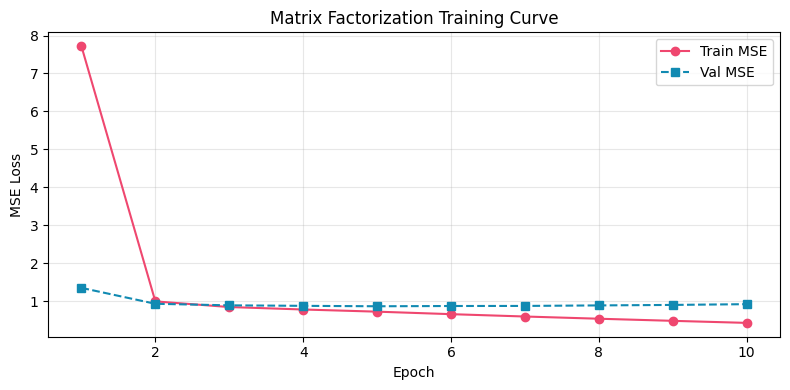


최종 Val RMSE: 0.9601
  (1~5점 평점 기준 평균 오차가 약 0.96점)


In [23]:
# ===== 실습 2B - Step 5: Loss 곡선 시각화 =====

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, 'o-', label='Train MSE', color='#ef476f')
plt.plot(range(1, EPOCHS+1), val_losses,   's--', label='Val MSE', color='#118ab2')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Matrix Factorization Training Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("mf_loss.png", dpi=150, bbox_inches='tight')
plt.show()

# 최종 RMSE
final_rmse = val_losses[-1] ** 0.5
print(f"\n최종 Val RMSE: {final_rmse:.4f}")
print(f"  (1~5점 평점 기준 평균 오차가 약 {final_rmse:.2f}점)")

In [24]:
# ===== 실습 2B - Step 6: 학습된 모델로 추천 =====

# 특정 유저에게 아직 보지 않은 영화 TOP-10 추천
target_user_id = 1  # 유저 ID 1번
target_user_idx = user2idx[target_user_id]

# 해당 유저가 이미 본 영화들
seen_movie_idxs = set(
    ratings[ratings["userId"] == target_user_id]["item_idx"].values
)

model_mf.eval()
with torch.no_grad():
    # 모든 아이템에 대한 예측 평점 계산
    all_items = torch.arange(num_items).to(device)
    user_tensor = torch.full((num_items,), target_user_idx, dtype=torch.long).to(device)
    scores = model_mf(user_tensor, all_items).cpu().numpy()

# 이미 본 영화 마스킹
scores[list(seen_movie_idxs)] = -999.0

# 상위 10개 추천
top10_idxs = np.argsort(scores)[::-1][:10]
idx2item = {v: k for k, v in item2idx.items()}

print(f"=== 유저 {target_user_id}번의 TOP-10 추천 영화 ===")
print(f"  (총 {len(seen_movie_idxs)}편 이미 시청)")
print("-" * 45)
for rank, idx in enumerate(top10_idxs, 1):
    movie_id = idx2item[idx]
    title = movies[movies['movieId'] == movie_id]['title'].values[0]
    print(f"  {rank:2d}. {title}  (예측 평점: {scores[idx]:.2f})")

=== 유저 1번의 TOP-10 추천 영화 ===
  (총 272편 이미 시청)
---------------------------------------------
   1. Boy's Life 2 (1997)  (예측 평점: 5.15)
   2. Ruling Class, The (1972)  (예측 평점: 5.11)
   3. Sweet Hereafter, The (1997)  (예측 평점: 5.03)
   4. Eve's Bayou (1997)  (예측 평점: 4.94)
   5. Waiting for Guffman (1996)  (예측 평점: 4.92)
   6. Kama Sutra: A Tale of Love (1996)  (예측 평점: 4.90)
   7. Bottle Rocket (1996)  (예측 평점: 4.89)
   8. Double vie de Véronique, La (Double Life of Veronique, The) (1991)  (예측 평점: 4.83)
   9. Local Hero (1983)  (예측 평점: 4.82)
  10. Quiet Room, The (1996)  (예측 평점: 4.79)


---

# 🕸️ 실습 2C: LightGCN 그래프 전파 1스텝 + 시각화

**학습 목표**:
- 유저-아이템 **이분 그래프(bipartite graph)** 인접행렬을 직접 구성한다
- 정규화된 이웃 임베딩 집계(aggregation) 1회를 구현하며 LightGCN 원리를 체감한다
- 학회원 이름을 매핑하여 그래프를 HTML로 시각화한다

### 📖 개념 복습

LightGCN의 핵심은 **단순하지만 강력한 전파 공식**:
$$e_u^{(k+1)} = \sum_{i \in N_u} \frac{1}{\sqrt{|N_u|} \cdot \sqrt{|N_i|}} \cdot e_i^{(k)}$$

행렬 형태: $E^{(k+1)} = \tilde{A} \cdot E^{(k)}$  
여기서 $\tilde{A} = D^{-1/2} A D^{-1/2}$ (정규화 인접 행렬)

**GCN과의 차이점**: 가중치 행렬 $W$와 활성화 함수 없음 → **오직 이웃 정보 집계만!**

In [ ]:
# ===== 실습 2C - Step 1: 데이터 준비 (implicit 변환 + 학회원 매핑) =====

import pandas as pd
import numpy as np
from scipy.sparse import coo_matrix, csr_matrix

# 학회원 29명 이름 (여기에 실제 이름을 넣어주세요!)
member_names = [
    "권유철", "김민아", "김지윤", "김진하", "김희연",
    "류시현", "방서영", "손영현", "오규원", "이수빈",
    "전수현", "정리나", "조대흠", "최록희", "한민영",
    "고유빈", "구준모", "권도영", "김태희", "박준상",
    "방상운", "신영은", "안가은", "이지영", "이채원",
    "장유경", "조민정", "조수현", "최윤지", "최지원"
]

# 평점 데이터 로드 (앞에서 이미 ratings 로드됨)
raw = ratings.copy()

# 가장 활동량이 많은 상위 30명 유저 ID → 학회원 이름 매핑
top_users = raw['userId'].value_counts().head(30).index
id_to_name_map = dict(zip(top_users, member_names))
raw['user_name'] = raw['userId'].map(id_to_name_map).fillna('Anonymous')

print("학회원 매핑 예시:")
print(raw[raw['user_name'] != 'Anonymous'][['userId', 'user_name']].drop_duplicates().head(5))

In [26]:
# ===== 실습 2C - Step 2: Implicit 데이터로 변환 + ID 리매핑 =====

# explicit(1~5점) → implicit(본 것=1, 안 본 것=0) 변환
raw_imp = raw.copy()
raw_imp["rating"] = 1

# 0-based 연속 인덱스 매핑
u2idx = {u: i for i, u in enumerate(sorted(raw_imp["userId"].unique()))}
v2idx = {v: i for i, v in enumerate(sorted(raw_imp["movieId"].unique()))}
raw_imp["u"] = raw_imp["userId"].map(u2idx)
raw_imp["v"] = raw_imp["movieId"].map(v2idx)

# 최소 3개 이상 상호작용한 유저만 유지
min_cnt = 3
user_cnt = raw_imp.groupby("u").size()
kept_users = set(user_cnt[user_cnt >= min_cnt].index)
df = raw_imp[raw_imp["u"].isin(kept_users)].copy()

# 필터링 후 재매핑 (빈틈 없이)
u_new = {u: i for i, u in enumerate(sorted(df["u"].unique()))}
v_new = {v: i for i, v in enumerate(sorted(df["v"].unique()))}
df["u"] = df["u"].map(u_new)
df["v"] = df["v"].map(v_new)

# 유저 인덱스 → 이름 매핑 저장
# (u, user_name)은 1:1이지만 명시적으로 중복 제거 후 매핑
final_user_map = df.drop_duplicates("u").set_index("u")["user_name"].to_dict()

n_users_lgcn = df["u"].nunique()
n_items_lgcn = df["v"].nunique()

print(f"n_users: {n_users_lgcn:,}  |  n_items: {n_items_lgcn:,}")
print(f"total interactions: {len(df):,}")

n_users: 943  |  n_items: 1,682
total interactions: 100,000


### ✏️ 빈칸 채우기: 이분 그래프 인접행렬 구성

LightGCN에서 유저-아이템 관계를 하나의 그래프로 표현합니다.

$$A = \begin{bmatrix} 0 & R \\ R^T & 0 \end{bmatrix}$$

- 유저 노드 인덱스: `0 ~ nU-1`
- 아이템 노드 인덱스: `nU ~ nU+nI-1` (아이템 인덱스에 nU를 더해줌)

| *** | 채워야 할 값 | 설명 |
|-----|------------|------|
| 1번째 `***` | `R_coo.col + nU` | 아이템 열 인덱스에 nU를 더해 아이템 노드 위치로 이동 |
| 2번째 `***` | `R_coo.col + nU` | lower 블록 행 인덱스 (아이템→유저 방향) |
| 3번째 `***` | `R_coo.row` | lower 블록 열 인덱스 (유저 인덱스) |
| 4번째 `***` | `upper + lower` | 두 블록을 합쳐 전체 인접행렬 완성 |
| 5번째 `***` | `norm_adj_lgcn @ E_0` | 정규화 인접행렬과 임베딩의 행렬곱 (1-step 전파) |


In [27]:
# ===== 실습 2C - Step 3: 이분 그래프 인접행렬 구성 =====

def build_interaction(dfx, n_u, n_i):
    """유저-아이템 상호작용 DataFrame → CSR 희소행렬 R 반환"""
    rows = dfx["u"].to_numpy()
    cols = dfx["v"].to_numpy()
    data = np.ones(len(rows), dtype=np.float32)
    return csr_matrix((data, (rows, cols)), shape=(n_u, n_i))


def build_norm_adj(R):
    """
    R (n_users × n_items) → 정규화 인접행렬 A_norm

    이분 그래프:
      A = [[0,   R  ],
           [R^T, 0  ]]

    아이템 노드 인덱스 = 아이템 인덱스 + nU  (유저 노드 다음에 배치)
    """
    nU, nI = R.shape
    R_coo = R.tocoo()

    # 윗 블록: 유저→아이템 (유저 행, 아이템 열에 nU 더함)
    upper = coo_matrix(
        (R_coo.data, (R_coo.row, ***)),   # ① 아이템 열 = col + nU
        shape=(nU + nI, nU + nI)
    )

    # 아랫 블록: 아이템→유저 (아이템 행에 nU 더함, 유저 열)
    lower = coo_matrix(
        (R_coo.data, (***, ***)),          # ② 행 = col+nU,  ③ 열 = row
        shape=(nU + nI, nU + nI)
    )

    # 두 블록 합산 → 전체 인접행렬 A
    A = (***).tocsr()                      # ④ upper + lower

    # D^{-1/2} 정규화
    degrees    = np.asarray(A.sum(axis=1)).ravel()
    d_inv_sqrt = np.zeros_like(degrees, dtype=np.float32)
    nz = degrees > 0
    d_inv_sqrt[nz] = degrees[nz] ** (-0.5)
    D = csr_matrix(
        (d_inv_sqrt, (np.arange(len(d_inv_sqrt)), np.arange(len(d_inv_sqrt)))),
        shape=A.shape
    )
    return D @ A @ D


R_lgcn        = build_interaction(df, n_users_lgcn, n_items_lgcn)
norm_adj_lgcn = build_norm_adj(R_lgcn)

print(f"R 크기: {R_lgcn.shape}")
print(f"norm_adj 크기: {norm_adj_lgcn.shape}")
print(f"  → {n_users_lgcn}(유저) + {n_items_lgcn}(아이템) = {n_users_lgcn + n_items_lgcn}개 노드")


R 크기: (943, 1682)
norm_adj 크기: (2625, 2625)
  → 943(유저) + 1682(아이템) = 2625개 노드


In [28]:
# ===== 실습 2C - Step 4: LightGCN 1-step 전파 직접 구현 [빈칸] =====
#
# LightGCN의 그래프 전파 공식:
#   E^(1) = norm_adj @ E^(0)
#
# E^(0): 초기 임베딩 (무작위 초기화)
# E^(1): 1번 전파 후 업데이트된 임베딩
#
# 핵심 의미: 유저 임베딩 = 자신이 본 아이템들의 임베딩 가중 평균
#             아이템 임베딩 = 자신을 본 유저들의 임베딩 가중 평균

# ─── 초기 임베딩 E^(0) 설정 ───────────────────────────────────────────
embed_dim = 16  # 시각화 목적이므로 작게
n_total_nodes = n_users_lgcn + n_items_lgcn

np.random.seed(42)
E_0 = np.random.randn(n_total_nodes, embed_dim).astype(np.float32) * 0.1

print(f"E_0 (초기 임베딩) 크기: {E_0.shape}")
print(f"  행: {n_total_nodes}개 노드 (유저 {n_users_lgcn} + 아이템 {n_items_lgcn})")
print(f"  열: {embed_dim}차원 임베딩")

# ─── 1-step 전파 E^(1) = norm_adj @ E^(0) ─────────────────────────────
# 힌트: scipy sparse matrix 곱셈은 norm_adj_lgcn.dot(E_0) 또는 norm_adj_lgcn @ E_0
# TODO ↓
# 1-step 전파: E^(1) = A_norm @ E^(0)
# (scipy sparse 곱셈 결과를 ndarray로 변환)
E_1 = np.asarray(***)  # ⑤ norm_adj_lgcn @ E_0

print(f"\nE_1 (1-step 전파 후) 크기: {E_1.shape}")

# ─── 유저 / 아이템 임베딩 분리 ───────────────────────────────────────
user_embs_0 = E_0[:n_users_lgcn]   # 초기 유저 임베딩
item_embs_0 = E_0[n_users_lgcn:]   # 초기 아이템 임베딩
user_embs_1 = E_1[:n_users_lgcn]   # 전파 후 유저 임베딩
item_embs_1 = E_1[n_users_lgcn:]   # 전파 후 아이템 임베딩

print(f"\n전파 전후 유저 임베딩 변화 (처음 3명):")
for i in range(3):
    name = final_user_map.get(i, f"User{i}")
    diff = np.linalg.norm(user_embs_1[i] - user_embs_0[i])
    print(f"  {name}: 변화량 = {diff:.4f}  (이웃 아이템 정보가 반영됨)")

E_0 (초기 임베딩) 크기: (2625, 16)
  행: 2625개 노드 (유저 943 + 아이템 1682)
  열: 16차원 임베딩

E_1 (1-step 전파 후) 크기: (2625, 16)

전파 전후 유저 임베딩 변화 (처음 3명):
  Anonymous: 변화량 = 0.3796  (이웃 아이템 정보가 반영됨)
  Anonymous: 변화량 = 0.3957  (이웃 아이템 정보가 반영됨)
  Anonymous: 변화량 = 0.3839  (이웃 아이템 정보가 반영됨)


In [29]:
# ===== 실습 2C - Step 5: '나와 취향이 비슷한 학회원은?' =====

from sklearn.metrics.pairwise import cosine_similarity

# 학회원(named member)들의 인덱스 추출
member_user_indices = [
    u for u, name in final_user_map.items()
    if name != 'Anonymous'
]

if len(member_user_indices) < 2:
    print("학회원 데이터가 부족합니다.")
else:
    # 전파 후 임베딩으로 유사도 계산
    member_embs = user_embs_1[member_user_indices]
    sim_matrix  = cosine_similarity(member_embs)

    member_names_list = [final_user_map[u] for u in member_user_indices]

    print("=" * 50)
    print("🤝 LightGCN 1-step 전파 기반 취향 유사도")
    print("=" * 50)

    # 각 학회원의 가장 취향이 비슷한 학회원 TOP-3 출력
    for i, (u_idx, name) in enumerate(zip(member_user_indices, member_names_list)):
        # 자기 자신 제외하고 유사도 기준 정렬
        sim_scores_i = list(enumerate(sim_matrix[i]))
        sim_scores_i = sorted(sim_scores_i, key=lambda x: x[1], reverse=True)
        sim_scores_i = [s for s in sim_scores_i if s[0] != i][:3]

        similar_members = [(member_names_list[j], f"{score:.3f}") for j, score in sim_scores_i]
        top1_name, top1_score = similar_members[0]
        print(f"  {name:6s} ← 가장 비슷한 취향: {top1_name} (유사도 {top1_score})")

🤝 LightGCN 1-step 전파 기반 취향 유사도
  손영현    ← 가장 비슷한 취향: 김태희 (유사도 0.763)
  오규원    ← 가장 비슷한 취향: 방서영 (유사도 0.527)
  권도영    ← 가장 비슷한 취향: 장유경 (유사도 0.660)
  정수현    ← 가장 비슷한 취향: 이지영 (유사도 0.701)
  김희연    ← 가장 비슷한 취향: 조민정 (유사도 0.636)
  한민영    ← 가장 비슷한 취향: 조민정 (유사도 0.430)
  신영은    ← 가장 비슷한 취향: 이지영 (유사도 0.757)
  안가은    ← 가장 비슷한 취향: 권유철 (유사도 0.772)
  김지윤    ← 가장 비슷한 취향: 최지원 (유사도 0.560)
  김태희    ← 가장 비슷한 취향: 손영현 (유사도 0.763)
  박준상    ← 가장 비슷한 취향: 고유빈 (유사도 0.640)
  방상운    ← 가장 비슷한 취향: 김진하 (유사도 0.702)
  정리나    ← 가장 비슷한 취향: 김희연 (유사도 0.476)
  고유빈    ← 가장 비슷한 취향: 안가은 (유사도 0.651)
  이채원    ← 가장 비슷한 취향: 고유빈 (유사도 0.585)
  이수빈    ← 가장 비슷한 취향: 조민정 (유사도 0.639)
  권유철    ← 가장 비슷한 취향: 안가은 (유사도 0.772)
  류시현    ← 가장 비슷한 취향: 이지영 (유사도 0.595)
  조민정    ← 가장 비슷한 취향: 이수빈 (유사도 0.639)
  조대흠    ← 가장 비슷한 취향: 이지영 (유사도 0.640)
  이지영    ← 가장 비슷한 취향: 신영은 (유사도 0.757)
  김진하    ← 가장 비슷한 취향: 방상운 (유사도 0.702)
  방서영    ← 가장 비슷한 취향: 오규원 (유사도 0.527)
  최윤지    ← 가장 비슷한 취향: 박준상 (유사도 0.448)
  김민아    ← 가장 비슷한 취향: 류시현 (유사도 0.586)
  구준모    ← 가장 비슷한 취

### 🌐 인터랙티브 그래프 시각화

학회원(사람 노드)과 영화(사각형 노드)의 추천 관계를 그래프로 확인해보세요!

| 노드/엣지 | 의미 |
|-----------|------|
| 🔴 빨강 원 | 학회원 |
| 🟢 초록 사각형 | 시청한 영화 |
| 🔵 파랑 사각형 | 추천 영화 |
| 🟡 노랑 사각형 | 시청+추천 겹침 |
| 회색 점선 | 시청 관계 |
| 파란 실선 | 추천 관계 |

> 드래그로 노드 이동, 스크롤로 줌, 노드 클릭 시 연결 강조!


In [ ]:
# ===== 실습 2C - Step 6: HTML 그래프 생성 =====

from IPython.display import display, HTML
import json, os

# ── 영화 제목 매핑 ─────────────────────────────────────────
item_path_lgcn = os.path.join(DATA_DIR, "ml-100k", "u.item")
items_df = pd.read_csv(item_path_lgcn, sep="|", encoding="latin-1",
                       header=None, usecols=[0, 1], names=["iid", "title"])
movieid2title = dict(zip(items_df["iid"], items_df["title"]))
idx2movieid   = df.drop_duplicates("v").set_index("v")["movieId"].to_dict()

def get_title(v_idx):
    mid = idx2movieid.get(v_idx, -1)
    return movieid2title.get(mid, "Item " + str(v_idx))[:22]

# ── 학회원 필터링 ──────────────────────────────────────────
viz_members = {u: name for u, name in final_user_map.items() if name != "Anonymous"}
u_list_viz  = [u for u in viz_members if u < n_users_lgcn]
print("시각화 학회원:", len(u_list_viz), "명")
if len(u_list_viz) == 0:
    raise RuntimeError("학회원 데이터가 없습니다. Step 1~2를 먼저 실행하세요.")

SEEN_CAP = 4
REC_K    = 4
train_items_by_user_lgcn = {u: set(R_lgcn[u].indices) for u in range(n_users_lgcn)}

seen_by_user_viz, recs_by_user_viz = {}, {}
seen_global_viz, rec_global_viz    = set(), set()

for u in u_list_viz:
    seen = list(train_items_by_user_lgcn.get(u, []))[:SEEN_CAP]
    seen_by_user_viz[u] = seen
    seen_global_viz.update(seen)
    sc = (item_embs_1 @ user_embs_1[u]).copy()
    for sv in train_items_by_user_lgcn.get(u, set()):
        if sv < len(sc): sc[sv] = -1e9
    topk = np.argsort(sc)[::-1][:REC_K].tolist()
    recs_by_user_viz[u] = topk
    rec_global_viz.update(topk)

both_viz  = seen_global_viz & rec_global_viz
seen_only = seen_global_viz - both_viz

def color_key(it):
    if it in both_viz:  return "both"
    if it in seen_only: return "seen"
    return "rec"

# ── 노드/엣지 데이터 직렬화 ───────────────────────────────
USER_COLORS = ["#ff4d6d","#ff6b35","#ff9f1c","#c084fc",
               "#34d399","#f472b6","#fb923c","#a78bfa",
               "#4ade80","#60a5fa"]

nodes_data, edges_data = [], []
for i, u in enumerate(u_list_viz):
    name = viz_members[u]
    n_seen = len(train_items_by_user_lgcn.get(u, set()))
    nodes_data.append({
        "id": "u"+str(u), "label": name, "type": "user",
        "color": USER_COLORS[i % len(USER_COLORS)],
        "info": "시청 "+str(n_seen)+"편  추천 "+str(REC_K)+"편"
    })
for it in sorted(seen_global_viz | rec_global_viz):
    ck = color_key(it)
    col = {"seen":"#2dd4bf", "rec":"#818cf8", "both":"#fbbf24"}[ck]
    nodes_data.append({
        "id": "i"+str(it), "label": get_title(it),
        "type": "movie", "color": col, "info": get_title(it)
    })
for u in u_list_viz:
    for it in seen_by_user_viz[u]:
        edges_data.append({"from":"u"+str(u),"to":"i"+str(it),"type":"seen"})
    for it in recs_by_user_viz[u]:
        edges_data.append({"from":"u"+str(u),"to":"i"+str(it),"type":"rec"})

gdata_json = json.dumps({"nodes": nodes_data, "edges": edges_data}, ensure_ascii=False)

# ── HTML 생성 (iframe 없이 div+canvas 직접 삽입) ───────────
# 고정 크기(800×600)로 canvas 생성 → iframe/window 크기 의존성 제로
GRAPH_W, GRAPH_H = 860, 620

html_out = (
"""<div id="rg_wrap" style="position:relative;width:860px;height:620px;"""
"""background:#0d1117;border-radius:14px;overflow:hidden;"""
"""border:1px solid #21262d;margin:8px 0;font-family:'Segoe UI',sans-serif">"""
"""<canvas id="rg_c" width="860" height="620" style="display:block"></canvas>"""

# UI 레이어
"""<div style="position:absolute;top:14px;left:50%;transform:translateX(-50%);"""
"""text-align:center;pointer-events:none">"""
"""<div style="color:#e6edf3;font-size:15px;font-weight:600;letter-spacing:2px">"""
"""LightGCN · 추천 시스템 그래프</div>"""
"""<div style="color:#8b949e;font-size:11px;margin-top:3px">"""
"""드래그: 이동 &nbsp;|&nbsp; 스크롤: 줌 &nbsp;|&nbsp; 노드 클릭: 연결 강조</div></div>"""

# 툴팁
"""<div id="rg_tip" style="display:none;position:absolute;background:rgba(13,17,23,.95);"""
"""border:1px solid rgba(255,255,255,.15);border-radius:9px;padding:9px 13px;"""
"""color:#f0f6fc;font-size:12px;pointer-events:none;z-index:9;"""
"""box-shadow:0 4px 20px rgba(0,0,0,.6);max-width:170px;line-height:1.6">"""
"""<div id="rg_tn" style="font-weight:700;font-size:13px;color:#79c0ff"></div>"""
"""<div id="rg_ti" style="color:#8b949e;font-size:11px;margin-top:2px"></div></div>"""

# 범례
"""<div style="position:absolute;bottom:16px;left:16px;background:rgba(13,17,23,.85);"""
"""border:1px solid rgba(255,255,255,.1);border-radius:10px;padding:12px 16px">"""
"""<div style="color:#79c0ff;font-size:10px;letter-spacing:2px;margin-bottom:8px">LEGEND</div>"""
"""<div style="display:flex;align-items:center;gap:7px;margin-bottom:5px;font-size:12px;color:#c9d1d9">"""
"""<div style="width:12px;height:12px;border-radius:50%;background:#ff4d6d;flex-shrink:0"></div>학회원</div>"""
"""<div style="display:flex;align-items:center;gap:7px;margin-bottom:5px;font-size:12px;color:#c9d1d9">"""
"""<div style="width:14px;height:9px;border-radius:3px;background:#2dd4bf;flex-shrink:0"></div>시청한 영화</div>"""
"""<div style="display:flex;align-items:center;gap:7px;margin-bottom:5px;font-size:12px;color:#c9d1d9">"""
"""<div style="width:14px;height:9px;border-radius:3px;background:#818cf8;flex-shrink:0"></div>추천 영화</div>"""
"""<div style="display:flex;align-items:center;gap:7px;font-size:12px;color:#c9d1d9">"""
"""<div style="width:14px;height:9px;border-radius:3px;background:#fbbf24;flex-shrink:0"></div>시청+추천</div>"""
"""</div>"""

# JavaScript
"""<script>
(function(){
const GW="""+str(GRAPH_W)+""", GH="""+str(GRAPH_H)+""";
const RAW="""+gdata_json+""";

const canvas = document.getElementById('rg_c');
const ctx    = canvas.getContext('2d');
const tip    = document.getElementById('rg_tip');
const tipN   = document.getElementById('rg_tn');
const tipI   = document.getElementById('rg_ti');
const wrap   = document.getElementById('rg_wrap');

// ── 노드 초기 위치 (황금각 구형 배치, 고정 크기 기준) ──────
const nodes = RAW.nodes.map((d,i)=>{
  const tot = RAW.nodes.length;
  const a   = (i/tot)*Math.PI*2;
  const R   = d.type==='user' ? GW*0.15 : GW*0.32+Math.random()*GW*0.06;
  return {...d,
    x: GW/2 + R*Math.cos(a + (d.type==='user'?0:0.3)),
    y: GH/2 + R*Math.sin(a + (d.type==='user'?0:0.3))*(GH/GW),
    vx:0, vy:0,
    r: d.type==='user' ? 16 : 10
  };
});
const nMap = {};
nodes.forEach(n=>nMap[n.id]=n);
const edges = RAW.edges.map(e=>({...e,a:nMap[e.from],b:nMap[e.to]})).filter(e=>e.a&&e.b);

// ── Force 시뮬레이션 ────────────────────────────────────────
for(let s=0;s<220;s++){
  const al=1-s/220;
  for(let i=0;i<nodes.length;i++)
    for(let j=i+1;j<nodes.length;j++){
      const a=nodes[i],b=nodes[j];
      const dx=b.x-a.x,dy=b.y-a.y,d=Math.sqrt(dx*dx+dy*dy)||1;
      const min=(a.r+b.r)*3.8;
      if(d<min){const f=(min-d)/d*0.55*al;a.vx-=dx*f;a.vy-=dy*f;b.vx+=dx*f;b.vy+=dy*f;}
    }
  edges.forEach(e=>{
    const dx=e.b.x-e.a.x,dy=e.b.y-e.a.y,d=Math.sqrt(dx*dx+dy*dy)||1;
    const f=(d-95)/d*0.04*al;
    e.a.vx+=dx*f;e.a.vy+=dy*f;e.b.vx-=dx*f;e.b.vy-=dy*f;
  });
  nodes.forEach(n=>{
    n.vx+=(GW/2-n.x)*0.003*al; n.vy+=(GH/2-n.y)*0.003*al;
    n.x+=n.vx; n.y+=n.vy; n.vx*=0.72; n.vy*=0.72;
    n.x=Math.max(n.r+4,Math.min(GW-n.r-4,n.x));
    n.y=Math.max(n.r+4,Math.min(GH-n.r-4,n.y));
  });
}
nodes.forEach(n=>n.baseY=n.y);

// ── 연결 맵 ─────────────────────────────────────────────────
const cmap={};
edges.forEach(e=>{
  if(!cmap[e.from])cmap[e.from]=new Set();
  if(!cmap[e.to])  cmap[e.to]  =new Set();
  cmap[e.from].add(e.to); cmap[e.to].add(e.from);
});

// ── pan/zoom ─────────────────────────────────────────────────
let tx=0,ty=0,sc=1,drag=false,dsx=0,dsy=0,vtx=0,vty=0;
canvas.addEventListener('mousedown',e=>{drag=true;dsx=e.offsetX;dsy=e.offsetY;vtx=tx;vty=ty;});
window.addEventListener('mouseup',()=>drag=false);
canvas.addEventListener('mousemove',e=>{
  if(drag){tx=vtx+(e.offsetX-dsx);ty=vty+(e.offsetY-dsy);}
  doHover(e);
});
canvas.addEventListener('wheel',e=>{
  e.preventDefault();
  const f=e.deltaY>0?0.88:1.14;
  tx=(tx-e.offsetX)*f+e.offsetX; ty=(ty-e.offsetY)*f+e.offsetY; sc*=f;
},{passive:false});

function toW(x,y){return{x:(x-tx)/sc,y:(y-ty)/sc};}

// ── hover/click ──────────────────────────────────────────────
let hov=null,sel=null;
function hitTest(ox,oy){
  const p=toW(ox,oy);
  for(let i=nodes.length-1;i>=0;i--){
    const n=nodes[i],dx=p.x-n.x,dy=p.y-n.y;
    const hit=n.type==='user'?Math.sqrt(dx*dx+dy*dy)<n.r+3
              :Math.abs(dx)<n.r*2.6+3&&Math.abs(dy)<n.r*1.6+3;
    if(hit)return n;
  }return null;
}
function doHover(e){
  hov=hitTest(e.offsetX,e.offsetY);
  if(hov){
    tipN.textContent=hov.label;
    tipI.textContent=hov.info;
    tip.style.display='block';
    const bx=Math.min(e.offsetX+14, GW-180);
    tip.style.left=bx+'px'; tip.style.top=(e.offsetY-8)+'px';
    canvas.style.cursor='pointer';
  }else{tip.style.display='none';canvas.style.cursor='default';}
}
canvas.addEventListener('click',e=>{
  const h=hitTest(e.offsetX,e.offsetY);
  sel=(h&&h!==sel)?h:null;
});

// ── draw ─────────────────────────────────────────────────────
let t=0;
function draw(){
  requestAnimationFrame(draw); t+=0.015;
  ctx.clearRect(0,0,GW,GH);

  // 배경
  const bg=ctx.createRadialGradient(GW/2,GH/2,0,GW/2,GH/2,GW*0.75);
  bg.addColorStop(0,'#161b22'); bg.addColorStop(1,'#0d1117');
  ctx.fillStyle=bg; ctx.fillRect(0,0,GW,GH);

  ctx.save(); ctx.translate(tx,ty); ctx.scale(sc,sc);

  const actSet=sel?cmap[sel.id]||new Set():null;

  // 엣지
  edges.forEach(e=>{
    const isAct=sel&&(e.a===sel||e.b===sel);
    const fade =sel&&!isAct;
    ctx.globalAlpha=fade?0.03:isAct?0.9:e.type==='seen'?0.2:0.5;
    ctx.beginPath(); ctx.moveTo(e.a.x,e.a.y);
    if(e.type==='rec'){
      const mx=(e.a.x+e.b.x)/2,my=(e.a.y+e.b.y)/2;
      const nx=-(e.b.y-e.a.y)*0.18,ny=(e.b.x-e.a.x)*0.18;
      ctx.quadraticCurveTo(mx+nx,my+ny,e.b.x,e.b.y);
      ctx.strokeStyle=isAct?'#a5b4fc':'#6366f1';
      ctx.lineWidth=isAct?2.5:1.5;
      ctx.setLineDash([]);
    }else{
      ctx.lineTo(e.b.x,e.b.y);
      ctx.strokeStyle='rgba(148,163,184,0.7)';
      ctx.lineWidth=1; ctx.setLineDash([5,7]);
    }
    ctx.stroke(); ctx.setLineDash([]); ctx.globalAlpha=1;
  });

  // 부유 애니메이션
  nodes.forEach((n,i)=>{if(n!==hov&&n!==sel)n.y=n.baseY+Math.sin(t*0.7+i*1.1)*0.9;});

  // 노드
  nodes.forEach(n=>{
    const isH=n===hov,isS=n===sel,isC=sel&&actSet&&actSet.has(n.id);
    const fade=sel&&!isS&&!isC;
    ctx.globalAlpha=fade?0.12:1;
    const pulse=1+(isH||isS?Math.sin(t*5)*0.07:0);

    if(n.type==='user'){
      // 글로우
      if(!fade){
        const g=ctx.createRadialGradient(n.x,n.y,0,n.x,n.y,n.r*4*pulse);
        g.addColorStop(0,n.color+'50'); g.addColorStop(1,n.color+'00');
        ctx.fillStyle=g; ctx.beginPath(); ctx.arc(n.x,n.y,n.r*4*pulse,0,Math.PI*2); ctx.fill();
      }
      // 구체 (하이라이트 그라디언트)
      const gr=ctx.createRadialGradient(n.x-n.r*0.3,n.y-n.r*0.35,0,n.x,n.y,n.r*pulse);
      gr.addColorStop(0,'#ffffff'); gr.addColorStop(0.25,n.color); gr.addColorStop(1,n.color+'bb');
      ctx.fillStyle=gr; ctx.beginPath(); ctx.arc(n.x,n.y,n.r*pulse,0,Math.PI*2); ctx.fill();
      ctx.strokeStyle=isH||isS?'#fff':n.color+'dd';
      ctx.lineWidth=isH||isS?2.5:1.5; ctx.stroke();
      // 이름 라벨
      ctx.globalAlpha=fade?0.12:1;
      ctx.fillStyle='#f0f6fc'; ctx.textAlign='center'; ctx.textBaseline='top';
      ctx.font=(isH||isS)?'bold 11px Segoe UI':'10px Segoe UI';
      ctx.fillText(n.label,n.x,n.y+n.r*pulse+4);

    }else{
      // 영화 노드 (둥근 사각형)
      const rw=n.r*2.6*pulse,rh=n.r*1.7*pulse,rx=n.x-rw/2,ry=n.y-rh/2,rd=5;
      if(!fade&&(isH||isS||isC)){
        const sg=ctx.createRadialGradient(n.x,n.y,0,n.x,n.y,rw*1.4);
        sg.addColorStop(0,n.color+'40'); sg.addColorStop(1,n.color+'00');
        ctx.fillStyle=sg; ctx.beginPath(); ctx.arc(n.x,n.y,rw*1.4,0,Math.PI*2); ctx.fill();
      }
      ctx.fillStyle=n.color+(fade?'25':'bb');
      ctx.strokeStyle=isH||isS?'#fff':n.color;
      ctx.lineWidth=isH||isS?2:1.2;
      ctx.beginPath();
      ctx.moveTo(rx+rd,ry); ctx.lineTo(rx+rw-rd,ry);
      ctx.quadraticCurveTo(rx+rw,ry,rx+rw,ry+rd);
      ctx.lineTo(rx+rw,ry+rh-rd); ctx.quadraticCurveTo(rx+rw,ry+rh,rx+rw-rd,ry+rh);
      ctx.lineTo(rx+rd,ry+rh); ctx.quadraticCurveTo(rx,ry+rh,rx,ry+rh-rd);
      ctx.lineTo(rx,ry+rd); ctx.quadraticCurveTo(rx,ry,rx+rd,ry);
      ctx.closePath(); ctx.fill(); ctx.stroke();
      ctx.fillStyle=fade?'rgba(200,200,200,0.25)':'#e6edf3';
      ctx.font=(isH||isS)?'bold 9px Segoe UI':'9px Segoe UI';
      ctx.textAlign='center'; ctx.textBaseline='middle';
      let lbl=n.label; if(ctx.measureText(lbl).width>rw-6)lbl=lbl.slice(0,11)+'..';
      ctx.fillText(lbl,n.x,n.y);
    }
    ctx.globalAlpha=1;
  });
  ctx.restore();
}
draw();
})();
</script></div>"""
)

# 파일로도 저장
html_file = """<!DOCTYPE html><html><head><meta charset="UTF-8">
<style>body{margin:0;background:#0d1117;display:flex;justify-content:center;padding:20px}</style>
</head><body>""" + html_out + """</body></html>"""

with open("members_recsys_graph.html","w",encoding="utf-8") as f:
    f.write(html_file)
print("저장 완료: members_recsys_graph.html")
print("노드:", len(nodes_data), " 엣지:", len(edges_data))
display(HTML(html_out))


---

# 📊 실습 정리 & 복습 퀴즈

## 오늘 배운 것

| 알고리즘 | 핵심 원리 | 데이터 형태 |
|----------|----------|------------|
| **CBF** (실습1) | 아이템 속성의 TF-IDF 벡터 코사인 유사도 | 아이템 메타데이터 |
| **SVD-MF** (실습2A) | $R \approx P Q^T$ 수학적 분해 → 잠재 공간 시각화 | 유저-아이템 평점 행렬 |
| **Embedding-MF** (실습2B) | `nn.Embedding` + dot product + MSE 역전파 | 유저-아이템 평점 |
| **LightGCN** (실습2C) | $E^{(k+1)} = \tilde{A} E^{(k)}$ 그래프 전파 | 유저-아이템 이분 그래프 |

---

## 🧩 복습 퀴즈

**Q1.** TF-IDF에서 IDF 값이 낮다는 것은 무엇을 의미하나요?

**Q2.** SVD의 `S` (특이값) 행렬에서 상위 k개만 사용하는 이유는 무엇인가요?

**Q3.** PyTorch에서 역전파 3단계(`zero_grad → backward → step`)를 이 순서로 실행해야 하는 이유를 설명해보세요.

**Q4.** LightGCN이 일반 GCN과 다른 점 2가지는 무엇인가요?

**Q5.** 정규화 인접행렬 $\tilde{A} = D^{-1/2} A D^{-1/2}$에서 $D^{-1/2}$를 곱하는 이유는 무엇인가요?

---

## 🚀 더 도전해보기

1. **실습 1 확장**: 영화 줄거리(`overview`) 텍스트도 `content`에 포함시켜 추천 결과가 어떻게 바뀌는지 비교해보세요.

2. **실습 2B 확장**: `EPOCHS`를 늘려 학습을 더 진행하고, RMSE가 어디서 수렴하는지 확인해보세요.

3. **실습 2C 확장**: `n_layers=2, 3`으로 전파를 여러 번 반복하고, 취향 유사도 결과가 바뀌는지 확인해보세요.